In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [15]:
df = pd.read_csv("indian_roads_dataset.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (20000, 24)
   accident_id        city        state   latitude  longitude        date  \
0            0        Pune  Maharashtra  18.680827  73.930388  2023-10-22   
1            1      Mumbai  Maharashtra  18.817732  72.790846  2023-05-21   
2            2      Mumbai  Maharashtra  19.096889  72.819424  2024-07-10   
3            3  Chandigarh       Punjab  30.787805  76.847507  2025-03-30   
4            4     Chennai   Tamil Nadu  12.965155  80.283313  2024-01-25   

    time  hour day_of_week  is_weekend  ... visibility  temperature  \
0   5:00     5      Sunday           1  ...        low           32   
1   4:00     4      Sunday           1  ...       high           34   
2  13:00    13   Wednesday           0  ...        low           21   
3  11:00    11      Sunday           1  ...        low           30   
4  16:00    16    Thursday           0  ...       high           24   

   traffic_density        cause accident_severity  vehicles_involved  \
0             high 

In [16]:
df = df.drop(columns=['accident_id', 'date', 'time', 'latitude', 'longitude', 'city', 'state'])
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes', 'traffic_signal', 'weather', 'visibility', 'temperature', 'traffic_density', 'cause', 'accident_severity', 'vehicles_involved', 'casualties', 'is_peak_hour', 'festival', 'risk_score']


In [17]:
print("Null values:\n", df.isnull().sum())
df = df.drop_duplicates()
print("\nShape after removing duplicates:", df.shape)

Null values:
 hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64

Shape after removing duplicates: (20000, 17)


In [18]:
categorical_cols = ['day_of_week', 'road_type', 'weather', 'visibility',
                    'traffic_density', 'cause', 'festival']

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

le_target = LabelEncoder()
df['accident_severity'] = le_target.fit_transform(df['accident_severity'])

print("Classes:", le_target.classes_)
print(df.head())

Classes: ['fatal' 'major' 'minor']
   hour  day_of_week  is_weekend  road_type  lanes  traffic_signal  weather  \
0     5            3           1          0      3               1        1   
1     4            3           1          2      4               0        0   
2    13            6           0          2      3               0        1   
3    11            3           1          2      1               1        1   
4    16            4           0          0      3               1        0   

   visibility  temperature  traffic_density  cause  accident_severity  \
0           1           32                0      4                  0   
1           0           34                1      4                  1   
2           1           21                2      4                  2   
3           1           30                0      0                  2   
4           0           24                1      0                  2   

   vehicles_involved  casualties  is_peak_hour  fes

In [19]:
X = df.drop(columns=['accident_severity'])
y = df['accident_severity']

print("X shape:", X.shape)
print("Class distribution:\n", y.value_counts())

X shape: (20000, 16)
Class distribution:
 accident_severity
2    11025
1     5988
0     2987
Name: count, dtype: int64


In [20]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Before SMOTE:", y.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_resampled).value_counts().to_dict())

Before SMOTE: {2: 11025, 1: 5988, 0: 2987}
After SMOTE: {0: 11025, 1: 11025, 2: 11025}


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (26460, 16)
Testing size: (6615, 16)


In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done!")

Scaling done!


In [23]:
accuracies = []
k_values = range(1, 21)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"K={k:2d}  →  Accuracy: {round(acc*100, 2)}%")

K= 1  →  Accuracy: 68.68%
K= 2  →  Accuracy: 65.06%
K= 3  →  Accuracy: 65.71%
K= 4  →  Accuracy: 65.49%
K= 5  →  Accuracy: 64.88%
K= 6  →  Accuracy: 64.76%
K= 7  →  Accuracy: 64.5%
K= 8  →  Accuracy: 65.05%
K= 9  →  Accuracy: 65.08%
K=10  →  Accuracy: 64.54%
K=11  →  Accuracy: 64.47%
K=12  →  Accuracy: 64.94%
K=13  →  Accuracy: 64.63%
K=14  →  Accuracy: 64.49%
K=15  →  Accuracy: 64.7%
K=16  →  Accuracy: 64.63%
K=17  →  Accuracy: 64.58%
K=18  →  Accuracy: 64.44%
K=19  →  Accuracy: 64.02%
K=20  →  Accuracy: 63.99%


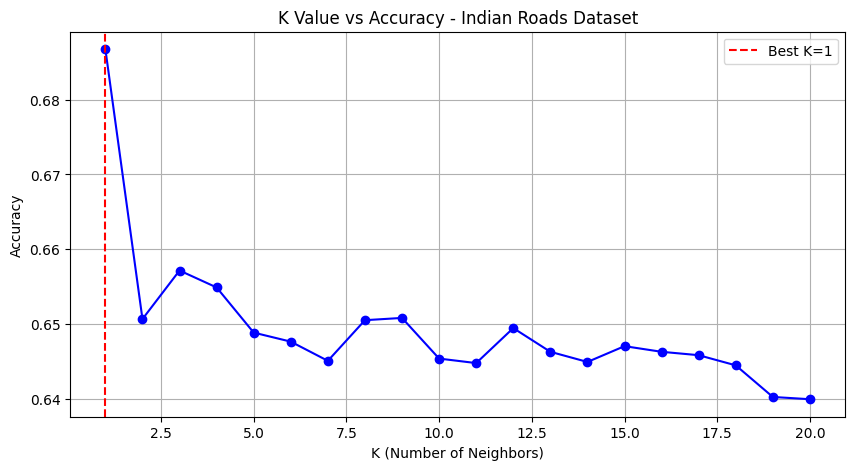

Best K: 1
Best Accuracy: 68.68 %


In [24]:
plt.figure(figsize=(10, 5))
plt.plot(list(k_values), accuracies, 'o-', color='blue')
plt.axvline(x=accuracies.index(max(accuracies))+1,
            color='red', linestyle='--',
            label=f'Best K={accuracies.index(max(accuracies))+1}')
plt.title("K Value vs Accuracy - Indian Roads Dataset")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

print("Best K:", accuracies.index(max(accuracies))+1)
print("Best Accuracy:", round(max(accuracies)*100, 2), "%")

In [25]:
param_grid = {'n_neighbors': range(1, 21)}

knn = KNeighborsClassifier()
grid = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)

print("Best K from GridSearchCV:", grid.best_params_)
print("Best Cross-Validation Accuracy:", round(grid.best_score_*100, 2), "%")

Best K from GridSearchCV: {'n_neighbors': 1}
Best Cross-Validation Accuracy: 66.66 %


In [26]:
best_k = grid.best_params_['n_neighbors']

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

y_pred_final = knn_final.predict(X_test_scaled)

print(f"Final Model with K={best_k}")
print("Accuracy:", round(accuracy_score(y_test, y_pred_final)*100, 2), "%")

Final Model with K=1
Accuracy: 68.68 %


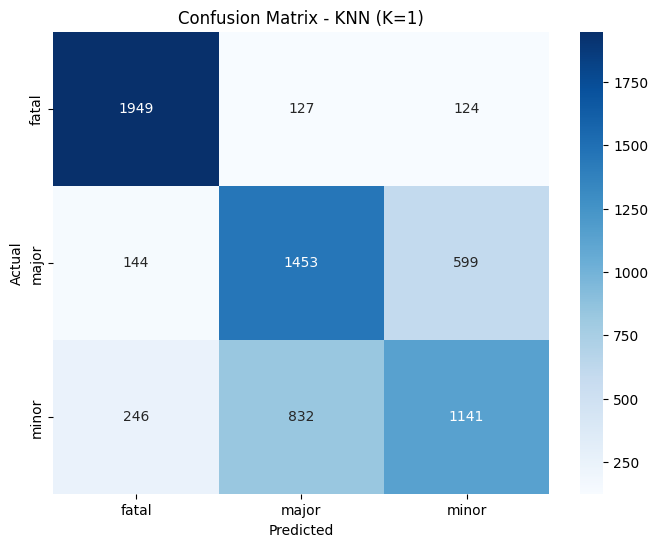

In [27]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title(f"Confusion Matrix - KNN (K={best_k})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
print("Classification Report:")
print(classification_report(y_test, y_pred_final, target_names=le_target.classes_))

Classification Report:
              precision    recall  f1-score   support

       fatal       0.83      0.89      0.86      2200
       major       0.60      0.66      0.63      2196
       minor       0.61      0.51      0.56      2219

    accuracy                           0.69      6615
   macro avg       0.68      0.69      0.68      6615
weighted avg       0.68      0.69      0.68      6615



In [29]:
print(f"{'Actual':<15} {'Predicted':<15} {'Result':<10}")
print("-" * 40)

for actual, predicted in zip(y_test[:10], y_pred_final[:10]):
    actual_name    = le_target.classes_[actual]
    predicted_name = le_target.classes_[predicted]
    match = "Correct" if actual == predicted else "Wrong"
    print(f"{actual_name:<15} {predicted_name:<15} {match:<10}")pip

Actual          Predicted       Result    
----------------------------------------
minor           major           Wrong     
fatal           fatal           Correct   
fatal           major           Wrong     
minor           fatal           Wrong     
minor           major           Wrong     
fatal           fatal           Correct   
major           major           Correct   
major           minor           Wrong     
minor           minor           Correct   
fatal           fatal           Correct   
